# Cue Conflict vs PSE — Pooled Data

All results use **pooled** (`all`) data and model fits.

Two versions:
1. **Bootstrap 95 % CI** — data error bars from 1000 parametric bootstrap resamples; models show point predictions (no error bars)
2. **SEM** — data error bars from bootstrap SEM; models show point predictions

In [1]:
import numpy as np
import pandas as pd
import os
import json

import matplotlib.pyplot as plt
import seaborn as sns

import loadData
from fitMainClass import fitPychometric as fitPsychometric

In [2]:
FONT = 18
plt.rcParams.update({
    'font.size': FONT, 'axes.labelsize': FONT, 'axes.titlesize': FONT + 2,
    'xtick.labelsize': FONT, 'ytick.labelsize': FONT, 'legend.fontsize': FONT,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.linewidth': 1.5, 'lines.linewidth': 2.0, 'lines.markersize': 8,
    'xtick.major.width': 1.5, 'ytick.major.width': 1.5,
    'xtick.major.size': 6,  'ytick.major.size': 6,
    'legend.frameon': True, 'legend.framealpha': 0.8, 'legend.edgecolor': 'black',
    'figure.dpi': 100, 'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'savefig.pad_inches': 0.1,
    'axes.grid': False,
})

In [3]:
# ── Constants ─────────────────────────────────────────────────
STANDARD_S = 0.5

def logpse_to_shift_s(mu_log, standard_s=STANDARD_S):
    """log-ratio mu  ->  PSE shift in seconds."""
    return (np.exp(mu_log) - 1) * standard_s

# ── Build fitter from pooled data ─────────────────────────────
pooled_data, _ = loadData.loadData('all_all.csv', verbose=False)
fitter = fitPsychometric(pooled_data, intensityVar='logDurRatio')
print(f'uniqueSensory : {sorted(fitter.uniqueSensory)}')
print(f'uniqueConflict: {fitter.uniqueConflict}')

uniqueSensory : [np.float64(0.1), np.float64(1.2)]
uniqueConflict: [np.float64(-0.25), np.float64(-0.17), np.float64(-0.08), np.float64(0.0), np.float64(0.08), np.float64(0.17), np.float64(0.25)]


In [4]:
# ═══════════════════════════════════════════════════════════════
#  Load pooled bootstrap & model fits
# ═══════════════════════════════════════════════════════════════

# ── 1. Pooled data bootstrap (1000 resamples) ────────────────
with open('bootstrapped_params/all/all_dataFit_bootstrapped_params.json') as f:
    data_boots = json.load(f)
print(f'Loaded {len(data_boots)} pooled data bootstrap samples')

# ── 2. Pooled model psychometric fits ─────────────────────────
MODEL_FILES = {
    'lognorm':           'psychometric_fits_simulated/all/all_lognorm_psychometricFits.json',
    'fusionOnlyLogNorm': 'psychometric_fits_simulated/all/all_fusionOnlyLogNorm_psychometricFits.json',
    'switchingFree':     'psychometric_fits_simulated/all/all_switchingFree_psychometricFits.json',
}
model_fits = {}
for name, path in MODEL_FILES.items():
    with open(path) as f:
        model_fits[name] = json.load(f)['fitParams']
    print(f'  {name}: {len(model_fits[name])} params')

# ── 3. Pooled model bootstraps (if available) ─────────────────
MODEL_BOOT_FILES = {
    'lognorm':           'bootstrapped_params/all/all_lognorm_psychometric_bootstrapped_params.json',
    'fusionOnlyLogNorm': 'bootstrapped_params/all/all_fusionOnlyLogNorm_psychometric_bootstrapped_params.json',
    'switchingFree':     'bootstrapped_params/all/all_switchingFree_psychometric_bootstrapped_params.json',
}
model_boots = {}
for name, path in MODEL_BOOT_FILES.items():
    if os.path.exists(path):
        with open(path) as f:
            model_boots[name] = json.load(f)
        print(f'  {name} bootstrap: {len(model_boots[name])} samples')
    else:
        print(f'  {name} bootstrap: not yet available')
if not model_boots:
    print('\n  Run bootstrap_pooled_models.py --nboots 200 to generate model bootstraps.')

Loaded 1000 pooled data bootstrap samples
  lognorm: 19 params
  fusionOnlyLogNorm: 19 params
  switchingFree: 19 params


In [5]:
# ═══════════════════════════════════════════════════════════════
#  Build data & model DataFrames
# ═══════════════════════════════════════════════════════════════

def build_data_stats(boots, fitter, param='mu'):
    """Extract bootstrap mean, SEM, 95% CI per condition."""
    pi = {'lambda': 0, 'mu': 1, 'sigma': 2}[param]
    rows = []
    for noise in sorted(fitter.uniqueSensory):
        for conflict in sorted(fitter.uniqueConflict):
            raw = np.array([fitter.getParams(b, conflict, noise)[pi]
                            for b in boots])
            if param == 'mu':
                raw = np.array([logpse_to_shift_s(v) for v in raw])
            lo, hi = np.percentile(raw, [2.5, 97.5])
            rows.append(dict(
                audioNoise=noise, conflict=conflict,
                mean=float(np.mean(raw)),
                sem=float(np.std(raw, ddof=1) / np.sqrt(len(raw))),
                ci_lo=float(lo), ci_hi=float(hi)))
    return pd.DataFrame(rows)


def build_model_stats(model_fits, fitter, param='mu', model_boots=None):
    """Pooled model predictions, with bootstrap 95% CI if available."""
    pi = {'lambda': 0, 'mu': 1, 'sigma': 2}[param]
    rows = []
    for name, params in model_fits.items():
        boots = model_boots.get(name) if model_boots else None
        for noise in sorted(fitter.uniqueSensory):
            for conflict in sorted(fitter.uniqueConflict):
                val = fitter.getParams(params, conflict, noise)[pi]
                if param == 'mu':
                    val = logpse_to_shift_s(val)
                row = dict(model=name, audioNoise=noise, conflict=conflict,
                           mean=float(val))
                if boots:
                    boot_vals = np.array([
                        fitter.getParams(b, conflict, noise)[pi] for b in boots])
                    if param == 'mu':
                        boot_vals = np.array([logpse_to_shift_s(v) for v in boot_vals])
                    lo, hi = np.percentile(boot_vals, [2.5, 97.5])
                    row['ci_lo'] = float(lo)
                    row['ci_hi'] = float(hi)
                    row['sem'] = float(np.std(boot_vals, ddof=1) / np.sqrt(len(boot_vals)))
                rows.append(row)
    return pd.DataFrame(rows)


data_stats  = build_data_stats(data_boots, fitter)
model_stats = build_model_stats(model_fits, fitter, model_boots=model_boots)

print('Data stats:')
print(data_stats.to_string(index=False))
print(f'\nModel stats ({len(model_stats)} rows):')
print(model_stats.to_string(index=False))

Data stats:
 audioNoise  conflict      mean      sem     ci_lo     ci_hi
        0.1     -0.25 -0.016816 0.000141 -0.025137 -0.007672
        0.1     -0.17 -0.008930 0.000112 -0.016053 -0.002123
        0.1     -0.08  0.007738 0.000119  0.000442  0.014875
        0.1      0.00  0.008606 0.000120  0.001617  0.015854
        0.1      0.08  0.014551 0.000152  0.004966  0.023870
        0.1      0.17  0.023554 0.000131  0.015742  0.031858
        0.1      0.25  0.025553 0.000127  0.017391  0.033126
        1.2     -0.25 -0.068597 0.000183 -0.080281 -0.057565
        1.2     -0.17 -0.048504 0.000172 -0.058637 -0.037391
        1.2     -0.08 -0.003376 0.000173 -0.014598  0.007109
        1.2      0.00  0.022097 0.000189  0.010680  0.033892
        1.2      0.08  0.056553 0.000248  0.042158  0.072323
        1.2      0.17  0.059423 0.000217  0.046562  0.073262
        1.2      0.25  0.078657 0.000231  0.064596  0.093012

Model stats (42 rows):
            model  audioNoise  conflict      mean

In [6]:
# ═══════════════════════════════════════════════════════════════
#  Plot function
# ═══════════════════════════════════════════════════════════════

MODEL_DISPLAY = {
    'lognorm':           'Causal inference',
    'fusionOnlyLogNorm': 'Forced fusion',
    'switchingFree':     'Cue switching',
}
MODEL_STYLE = {
    'lognorm':           dict(ls='-',  mk='o'),
    'fusionOnlyLogNorm': dict(ls='--', mk='s'),
    'switchingFree':     dict(ls=':',  mk='^'),
}


def plot_conflict_vs_pse(data_df, model_df, error_type='ci95', save_tag=''):
    """Two-panel plot (low / high noise).

    error_type:
      'ci95' — asymmetric bootstrap 95% CI from ci_lo/ci_hi
      'sem'  — symmetric ± SEM from sem column
    """
    FS = 18
    use_ci = (error_type == 'ci95'
              and {'ci_lo', 'ci_hi'}.issubset(data_df.columns))

    audio_levels = sorted(data_df['audioNoise'].unique())
    panel_titles = ['A)  Low auditory noise', 'B)  High auditory noise']

    model_names = sorted(model_df['model'].unique()) if model_df is not None else []
    palette = sns.color_palette('dark', n_colors=max(3, len(model_names)))
    model_colors = {m: palette[i] for i, m in enumerate(model_names)}

    all_series = ['__data__'] + model_names
    mid = (len(all_series) - 1) / 2
    offsets = {s: (i - mid) * 15.0 for i, s in enumerate(all_series)}

    fig, axes = plt.subplots(1, len(audio_levels), figsize=(12, 6), sharey=True)
    if len(audio_levels) == 1:
        axes = [axes]

    from matplotlib.lines import Line2D
    handles, labels = [], []
    models_done = set()

    for pi, (ax, noise) in enumerate(zip(axes, audio_levels)):
        sd = data_df[data_df['audioNoise'] == noise].sort_values('conflict')
        x = sd['conflict'].to_numpy(float) * 1000
        y = sd['mean'].to_numpy(float) * 1000

        if use_ci:
            y_lo = sd['ci_lo'].to_numpy(float) * 1000
            y_hi = sd['ci_hi'].to_numpy(float) * 1000
            yerr = np.vstack([y - y_lo, y_hi - y])
        else:
            yerr = sd['sem'].to_numpy(float) * 1000

        ax.errorbar(x + offsets['__data__'], y, yerr=yerr, color='black',
                    fmt='o', capsize=6, lw=1.8, capthick=1.5, zorder=6)
        if pi == 0:
            handles.append(Line2D([0],[0], color='black', marker='o',
                                  lw=1.8, markersize=7))
            labels.append('Data')

        for mname in model_names:
            sm = model_df[(model_df['audioNoise'] == noise) &
                          (model_df['model'] == mname)].sort_values('conflict')
            if sm.empty:
                continue
            c  = model_colors[mname]
            ls = MODEL_STYLE.get(mname, {}).get('ls', '-')
            mk = MODEL_STYLE.get(mname, {}).get('mk', 'o')
            xm = sm['conflict'].to_numpy(float) * 1000 + offsets.get(mname, 0)
            ym = sm['mean'].to_numpy(float) * 1000

            has_model_ci = (use_ci and 'ci_lo' in sm.columns
                            and sm['ci_lo'].notna().all())
            has_model_sem = ('sem' in sm.columns
                             and sm['sem'].notna().all())

            if has_model_ci:
                m_lo = sm['ci_lo'].to_numpy(float) * 1000
                m_hi = sm['ci_hi'].to_numpy(float) * 1000
                m_yerr = np.vstack([ym - m_lo, m_hi - ym])
            elif has_model_sem and error_type == 'sem':
                m_yerr = sm['sem'].to_numpy(float) * 1000
            else:
                m_yerr = None

            if m_yerr is not None:
                ax.errorbar(xm, ym, yerr=m_yerr, color=c, linestyle=ls,
                            marker=mk, markerfacecolor='white',
                            markeredgewidth=1.3, capsize=4, lw=2.5,
                            markersize=7, zorder=4)
            else:
                ax.plot(xm, ym, color=c, ls=ls, marker=mk,
                        markerfacecolor='white', markeredgewidth=1.3,
                        lw=2.5, markersize=7, zorder=4)

            if mname not in models_done:
                handles.append(Line2D([0],[0], color=c, ls=ls, marker=mk,
                                      markerfacecolor='white',
                                      markeredgewidth=1.3, lw=2.5, markersize=7))
                labels.append(MODEL_DISPLAY.get(mname, mname))
                models_done.add(mname)

        ax.axhline(0, color='gray', ls='--', lw=1, alpha=.7)
        ax.axvline(0, color='gray', ls='--', lw=1, alpha=.7)
        ax.set_title(panel_titles[pi], fontsize=FS, loc='left', pad=12)
        ax.set_xticks([-250, -170, -80, 0, 80, 170, 250])
        ax.set_xticklabels([str(t) for t in [-250,-170,-80,0,80,170,250]],
                           fontsize=FS-2)
        ax.tick_params(axis='both', labelsize=FS)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    axes[0].set_ylabel('PSE shift (ms)', fontsize=FS)
    fig.supxlabel('Cue conflict (ms)', fontsize=FS, x=0.415)

    model_has_ci = ('ci_lo' in model_df.columns
                     and model_df['ci_lo'].notna().any()) if model_df is not None else False
    if use_ci:
        note = 'Bootstrap 95% CI' if model_has_ci else 'Data: bootstrap 95% CI'
    else:
        note = '±SEM' if model_has_ci else 'Data: ±SEM'
    handles.append(Line2D([],[],color='none'))
    labels.append(note)

    fig.legend(handles, labels, loc='center right',
               bbox_to_anchor=(1.01, 0.5), fontsize=FS-2,
               frameon=True, edgecolor='black', fancybox=False)
    plt.tight_layout(rect=(0, 0.05, 0.83, 1))

    tag = save_tag or error_type
    plt.savefig(f'aggregated_mu_vs_models_{tag}.png', dpi=200, bbox_inches='tight')
    plt.savefig(f'aggregated_mu_vs_models_{tag}.pdf', dpi=900, format='pdf',
                bbox_inches='tight')
    plt.show()

print('Plot function defined \u2713')

Plot function defined ✓


## Version 1 — Bootstrap 95 % CI

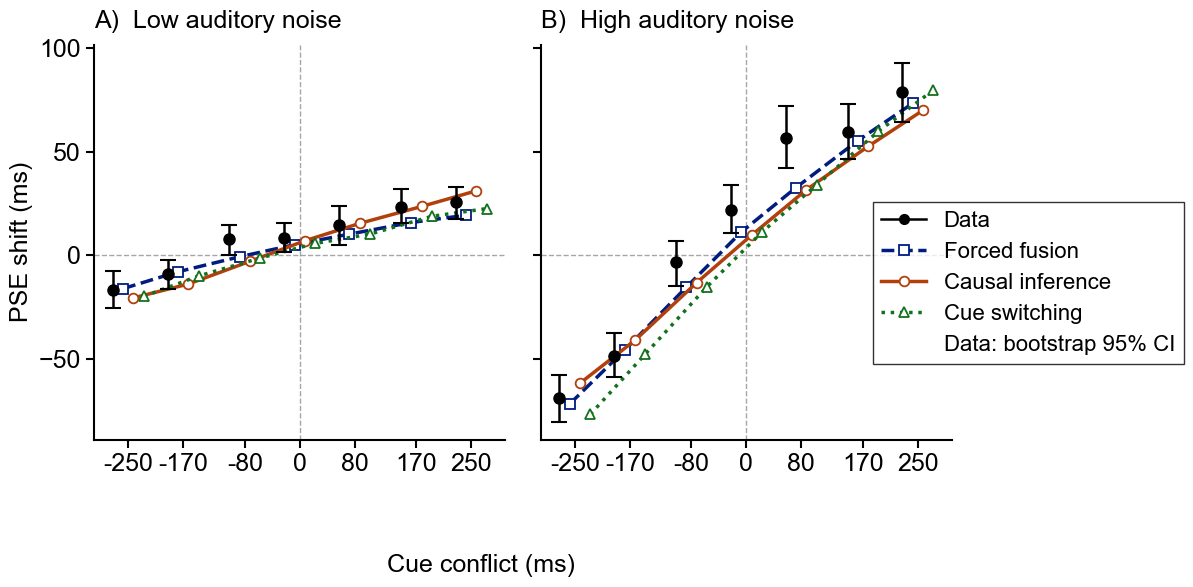

In [7]:
plot_conflict_vs_pse(data_stats, model_stats, error_type='ci95',
                     save_tag='bootstrap_ci95')

## Version 2 — SEM

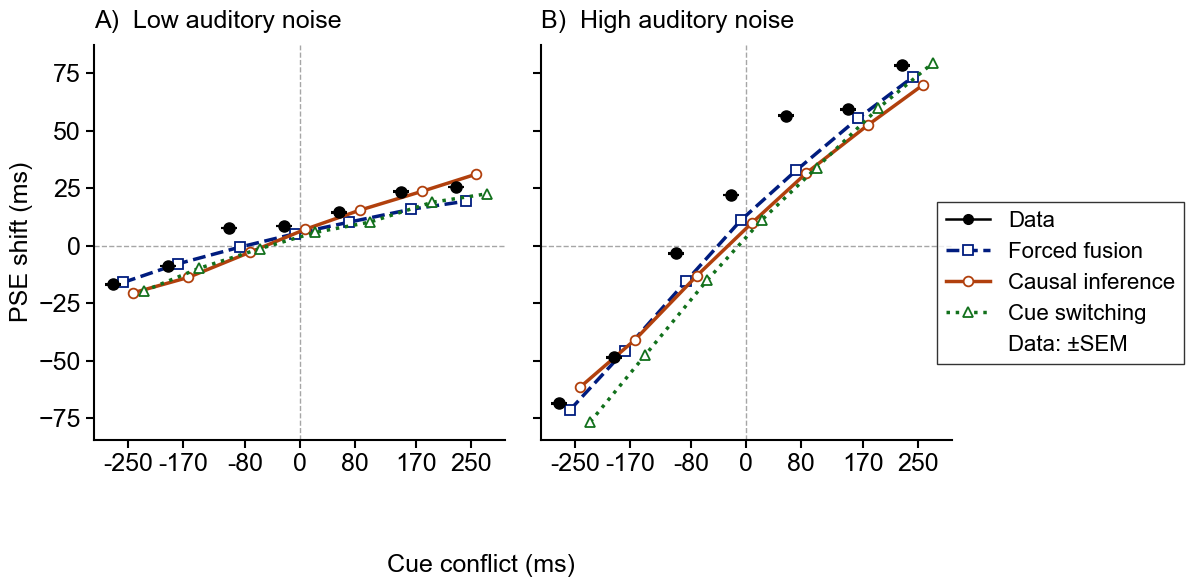

In [8]:
plot_conflict_vs_pse(data_stats, model_stats, error_type='sem',
                     save_tag='sem')